# Temperature dependence plots

Plots of numerical Lamb wave speeds from the dynamical cores for different temperatures,
and compare to theoretical Lamb and gravity wave speeds.

Used to make figures 2 and 3 in the paper.

In [18]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from functions import *

In [19]:
# Which test are we looking at??
test = 'p_pert'
#test = 'acid'

# Isothermal temperatures
T_range = np.linspace(200, 350, 100)
#T_vals = ([250,275,300,325,350])
T_vals = ([250,275,300,325])

In [20]:
# Manually add the wavespeeds, obtained using the SE dynamical core.
SE_speeds = np.array([313.6,329.0,343.5,357.9])
FV3_speeds = np.array([313.6,329.0,343.9,357.8])
MPAS_speeds = np.array([323.2,338.2,353.6,367.4])
MPAS_no_diff_speeds = np.array([314.6,330.0,344.8,359.2])
FV3_subcycled_speeds = np.array([310.9,326.0,340.1,354.2])

In [21]:
# Key parameters
gamma = 7./5.
Rd = 287.04
g = 9.81
cp = 1004
kappa = 2./7.

In [22]:
# Compute speeds
lamb_cs_range = np.sqrt(gamma*Rd*T_range)

# For a pressure coordinate
zT = [50000.]
lamb_cs_p_coord = np.zeros(len(T_range))
for i in np.arange(len(T_range)):
    H = Rd*T_range[i]/g
    root, height, speed = p_coord_speeds(zT, H, g, kappa)
    lamb_cs_p_coord[i] = speed[0]

#print(lamb_cs_p_coord)

/glade/derecho/scratch/timand/tmp/ipykernel_90275/1866689398.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c_g_K0_p_mbar1[i] = p_coord_grav_speeds(np.array([zT_val]), H_range[i], g, kappa, 1)[2]


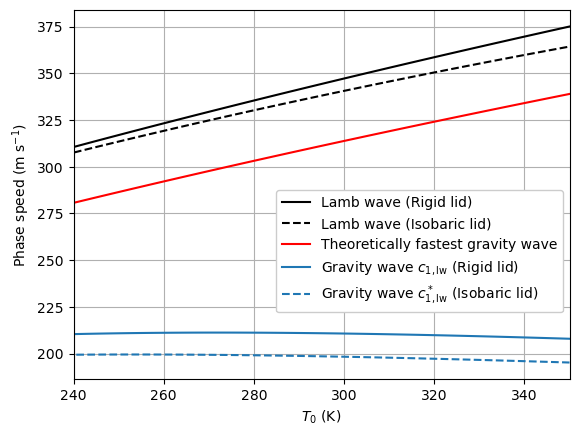

In [37]:
# What about comparing Lamb waves and the fastest gravity wave?
N_range = np.sqrt(g**2/(cp*T_range))
H_range = Rd*T_range/g

cs_range = lamb_cs_range

zT_val = 50e3

def gravity_wave_speed(N, H, K, m):
    # Simplified
    #return N/np.sqrt(K**2 + m**2 + (1/(4*H**2)))
    # More accurate
    return 2*N*H/np.sqrt(K**2 + 1 + 4*(m**2)*(H**2))

#c_g = 2*N_range*H_range
c_g = 2*Rd*np.sqrt(T_range/cp)

# Fastest gravity wave
c_g_K0_m0 = 2*N_range*H_range

# Other gravity waves
c_g_K1_m0 = gravity_wave_speed(N_range, H_range, 1/H_range, 0)
c_g_K0_m1 = gravity_wave_speed(N_range, H_range, 0, 1/H_range)
c_g_K1_m1 = gravity_wave_speed(N_range, H_range, 1/H_range, 1/H_range)

# Analytical expression for w=0 boundary conditions
mbar1 = np.pi/zT_val
c_g_K0_mbar0 = gravity_wave_speed(N_range, H_range, 0, 0)
c_g_K0_mbar1 = gravity_wave_speed(N_range, H_range, 0, mbar1)

# Numerical solution for Ln=0 top boundary condition
c_g_K0_p_mbar1 = np.zeros(len(H_range))
for i in np.arange(len(H_range)):
    c_g_K0_p_mbar1[i] = p_coord_grav_speeds(np.array([zT_val]), H_range[i], g, kappa, 1)[2]

plt.figure()
plt.plot(T_range, lamb_cs_range, label='Lamb wave (Rigid lid)', c='k')
plt.plot(T_range, lamb_cs_p_coord, label=r'Lamb wave (Isobaric lid)', c='k', linestyle='dashed')
plt.plot(T_range, c_g, label='Theoretically fastest gravity wave', c='r')
plt.plot(T_range, c_g_K0_mbar1, label=r'Gravity wave $c_{1, \text{lw}}$ (Rigid lid)', c='C0')
plt.plot(T_range, c_g_K0_p_mbar1, label=r'Gravity wave $c^*_{1, \text{lw}}$ (Isobaric lid)', c='C0', linestyle='dashed')
#plt.plot(T_range, c_g_K0_m0, label=r'Gravity wave, $k_{\text{h}} \ll 1/(2H)$, $n=1$')
#plt.plot(T_range, c_g_K1_m0, label=r'Gravity wave, $K=1/H$, $m=0$')
#plt.plot(T_range, c_g_K0_mbar1, label=r'Gravity wave, $k_{\text{h}} \ll 1/(2H)$, $\overline{m}=1$')
plt.xlabel(r'$T_0$ (K)')
plt.ylabel(r'Phase speed (m s$^{-1}$)')
plt.xlim([240,350])
#plt.ylim([280,400])
plt.legend(framealpha=1.0, bbox_to_anchor=(1, 0.53))
plt.grid()

plt.savefig(f'figures/lamb_and_gravity_waves.png', dpi=500, bbox_inches='tight')

plt.show()

27.273704697828293 36.079719980933874


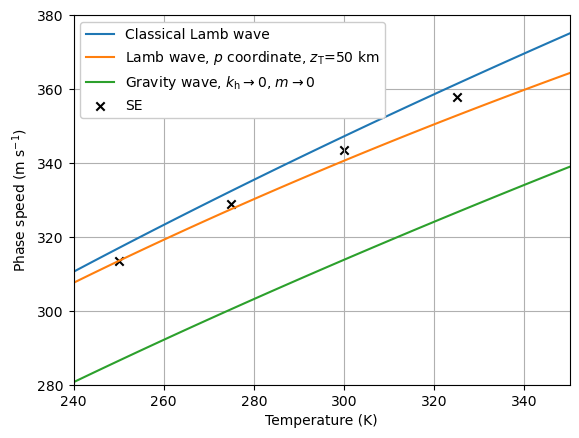

In [24]:
# Make the figure
plt.figure()
plt.plot(T_range, lamb_cs_range, label='Classical Lamb wave')
plt.plot(T_range, lamb_cs_p_coord, label=r'Lamb wave, $p$ coordinate, $z_{\text{T}}$=50 km')
plt.plot(T_range, c_g_K0_m0, label=r'Gravity wave, $k_{\text{h}}\rightarrow0$, $m\rightarrow0$')
plt.scatter(T_vals, SE_speeds, c='k', marker = 'x', label='SE')

plt.xlabel('Temperature (K)')
plt.ylabel(r'Phase speed (m s$^{-1}$)')
plt.xlim([240,350])
plt.ylim([280,380])

plt.legend(framealpha=1)
plt.grid()

if test == 'p_pert':
    #plt.title('Test case 1')
    plt.savefig(f'figures/p_pert_SE_speed_with_T0.jpg', bbox_inches='tight')
elif test == 'acid':
    #plt.title('Test case 2')
    plt.savefig(f'figures/acid_SE_speed_with_T0.jpg', bbox_inches='tight')

# What is the difference between these speeds?
diff = lamb_cs_range - c_g_K0_m0
print(np.min(diff), np.max(diff))


plt.show()


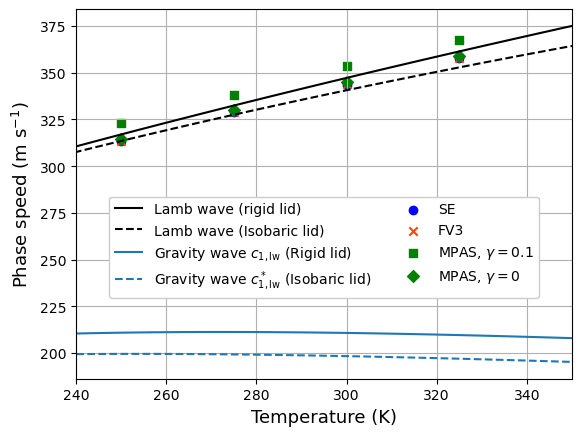

In [38]:
# Make the figure
plt.figure()
plt.plot(T_range, lamb_cs_range, label='Lamb wave (rigid lid)', c='k')
plt.plot(T_range, lamb_cs_p_coord, label=r'Lamb wave (Isobaric lid)', c='k', linestyle='dashed')
#plt.plot(T_range, c_g_K0_m0, label=r'Gravity wave, $k_{\text{h}} \ll 1/(2H)$, $m=0$')
plt.plot(T_range, c_g_K0_mbar1, label=r'Gravity wave $c_{1, \text{lw}}$ (Rigid lid)', c='C0')
plt.plot(T_range, c_g_K0_p_mbar1, label=r'Gravity wave $c^*_{1, \text{lw}}$ (Isobaric lid)', c='C0', linestyle='dashed')
plt.scatter(T_vals, SE_speeds, c='b', marker = 'o', label='SE')
plt.scatter(T_vals, FV3_speeds, c='orangered', marker = 'x', label='FV3')
plt.scatter(T_vals, MPAS_speeds, c='g', marker = 's', label=r'MPAS, $\gamma=0.1$')
plt.scatter(T_vals, MPAS_no_diff_speeds, c='g', marker = 'D', label=r'MPAS, $\gamma=0$')
#plt.scatter(T_vals, FV3_subcycled_speeds, c='k', marker = '>', label='FV3, subcycled')

plt.xlabel('Temperature (K)', size=13)
plt.ylabel(r'Phase speed (m s$^{-1}$)', size=13)
plt.xlim([240,350])
#plt.ylim([200,380])
#plt.ylim([280,380])

plt.legend(framealpha=1, loc='lower center', bbox_to_anchor=(0.5, 0.2), ncol=2)
plt.grid()

plt.savefig(f'figures/all_dycores_speed_with_T0.png',dpi=500, bbox_inches='tight')


[30.71848545 20.04295526 11.83451352]
[30.40542806 18.10626455  8.29066243]


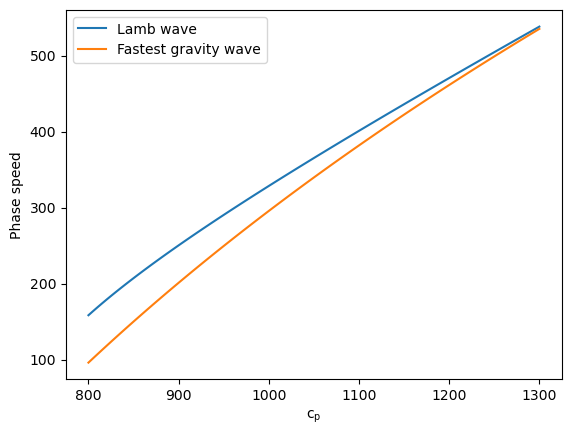

In [26]:
# Compare the factor for Lamb and gravity waves
cps = np.array([1257, 1005, 838])
cv = 718

T0 = 275

lamb_fact = np.sqrt(cps*(cps/cv - 1))
grav_fact = 2*(cps-cv)/np.sqrt(cps)

print(lamb_fact)
print(grav_fact)

# At a fixed T0, how do these vary?
cp_range = np.linspace(800, 1300, 100)

lamb_fact_range = np.sqrt(cp_range*(cp_range/cv - 1))
grav_fact_range = 2*(cp_range-cv)/np.sqrt(cp_range)

plt.figure()
plt.plot(cp_range, lamb_fact_range*np.sqrt(T0), label='Lamb wave')
plt.plot(cp_range, grav_fact_range*np.sqrt(T0), label='Fastest gravity wave')
plt.ylabel('Phase speed')
plt.xlabel(r'c$_{\text{p}}$')
plt.legend()

plt.savefig(f'figures/lamb_and_gravity_cp.jpg', bbox_inches='tight')

plt.show()

958.526892430279
350.0


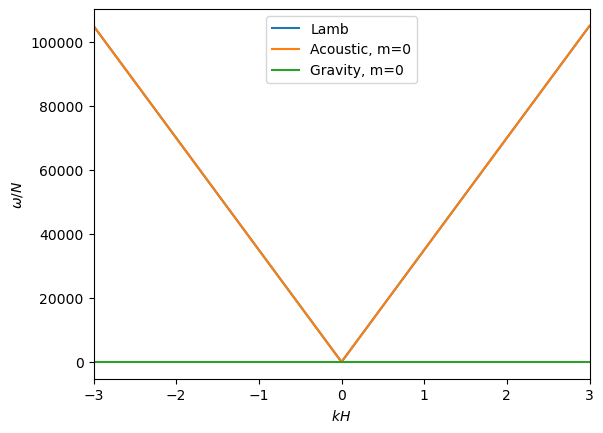

In [27]:
# Try and replicate the Vallis plot.

H = 7000
N = 0.01
T0 = g**2/(N**2*cp)
print(T0)
cs = np.sqrt(gamma*Rd*T0)
cs = 5*N*H
print(cs)

kH_range = np.linspace(-3,3,1000)
lamb_omega = cs*np.abs(kH_range)
acoustic_omega = cs*np.sqrt(kH_range**2 + (1/(4*(H**2))))
cg_m0_omega = N*np.abs(kH_range)/np.sqrt(kH_range**2 + 1 + (1/(4*(H**2))))

plt.figure()
plt.plot(kH_range, lamb_omega/N, label='Lamb')
plt.plot(kH_range, acoustic_omega/N, label='Acoustic, m=0')
plt.plot(kH_range, cg_m0_omega/N, label='Gravity, m=0')

plt.ylabel(r"$\omega/N$")
plt.xlabel(r"$kH$")
plt.xlim([-3,3])

plt.legend()

plt.show()